In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
from statsmodels.tsa.base.datetools import dates_from_str
from statsmodels.tsa.api import VAR
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Lasso
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam

from torch.utils.data import DataLoader, TensorDataset
import pytorch_lightning as pl

# Set plot style for better aesthetics
plt.style.use('seaborn-v0_8-whitegrid')
import warnings
warnings.filterwarnings("ignore")

In [3]:
iv_data = pd.read_csv('10years_SPX_IVS.csv')
iv_data

,Dates,30DAY_IMPVOL_80%MNY_DF,30DAY_IMPVOL_90.0%MNY_DF,30DAY_IMPVOL_95.0%MNY_DF,30DAY_IMPVOL_97.5%MNY_DF,30DAY_IMPVOL_100.0%MNY_DF,30DAY_IMPVOL_102.5%MNY_DF,30DAY_IMPVOL_105.0%MNY_DF,30DAY_IMPVOL_110.0%MNY_DF,30DAY_IMPVOL_120%MNY_DF,...,18MTH_IMPVOL_120%MNY_DF,24MTH_IMPVOL_80%MNY_DF,24MTH_IMPVOL_90.0%MNY_DF,24MTH_IMPVOL_95.0%MNY_DF,24MTH_IMPVOL_97.5%MNY_DF,24MTH_IMPVOL_100.0%MNY_DF,24MTH_IMPVOL_102.5%MNY_DF,24MTH_IMPVOL_105.0%MNY_DF,24MTH_IMPVOL_110.0%MNY_DF,24MTH_IMPVOL_120%MNY_DF
0,4/1/2016,31.4422,20.4818,15.7749,13.5518,11.1926,8.7991,8.6680,12.3428,13.0078,...,11.8507,22.6374,20.1359,18.9134,18.3122,17.6810,17.0812,16.4947,15.3507,13.3202
1,4/4/2016,32.3816,21.0527,16.4633,14.4232,12.1854,9.7695,9.1445,12.4163,13.2117,...,12.0997,22.8203,20.3300,19.1046,18.4937,17.8915,17.2888,16.7016,15.5572,13.5400
2,4/5/2016,32.8637,22.0677,17.6430,15.6324,13.4519,11.2138,9.7895,12.3206,12.3206,...,12.5537,23.2521,20.7511,19.5040,18.8611,18.3484,17.7543,17.1416,15.9772,13.9185
3,4/6/2016,32.3115,20.9377,16.4275,14.4957,12.2162,9.9239,8.8714,11.5959,11.5959,...,12.2230,22.9935,20.4688,19.2367,18.6073,18.0355,17.4445,16.8486,15.6908,13.6485
4,4/7/2016,33.5882,22.9630,18.5421,16.4382,14.1363,11.4923,9.7613,11.6225,11.7970,...,12.8713,23.5757,21.0630,19.8167,19.1972,18.6367,18.0572,17.4823,16.3173,14.2314
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2642,5/19/2026,36.3007,24.9829,20.1980,17.9325,15.3420,13.4098,12.3552,12.9116,19.7180,...,14.5225,24.6998,22.3562,21.1966,20.6092,18.9822,18.4450,17.9264,16.9253,15.2512
2643,5/20/2026,35.9650,24.5599,19.5751,17.2373,15.0037,13.4033,12.5152,13.4071,20.2456,...,14.5506,24.5622,22.2231,21.0593,20.4780,19.3770,18.3458,17.8333,16.8508,15.2362
2644,5/21/2026,36.2621,24.3449,19.1241,16.7278,14.4524,12.9001,12.1053,13.1761,20.5820,...,14.4419,24.4429,22.1017,20.9393,20.3690,18.8140,18.2213,17.7088,16.7347,15.1386
2645,5/22/2026,36.9736,24.5802,19.2580,16.8579,14.5497,13.0436,12.3963,13.9258,21.1173,...,14.5066,24.4502,22.1069,20.9575,20.3814,19.3243,18.2352,17.7266,16.7621,15.1779


### Extract and visualize IVS

dict shape: 2647, (7, 9)
index: date, value: (time_to_maturity, moneyness)
date: 5/25/2026


,80.0%,90.0%,95.0%,97.5%,100.0%,102.5%,105.0%,110.0%,120.0%
1M,36.9736,24.5802,19.2580,16.8579,14.5497,13.0436,12.3963,13.9258,21.1173
2M,31.8843,22.9178,18.8797,17.0250,15.0947,13.8278,13.0769,12.6767,15.9517
3M,29.7102,22.3476,18.8872,17.2840,15.6730,14.4643,13.6851,13.0045,14.4227
6M,27.2610,22.1031,19.5432,18.2950,16.8975,15.8775,15.0614,14.0270,13.4736
12M,25.4812,21.9476,20.2158,19.3502,17.8586,17.0333,16.3092,15.0802,13.8173
18M,24.8256,21.9908,20.6064,19.9190,18.7814,17.8050,17.2061,16.1075,14.5066
24M,24.4502,22.1069,20.9575,20.3814,19.3243,18.2352,17.7266,16.7621,15.1779


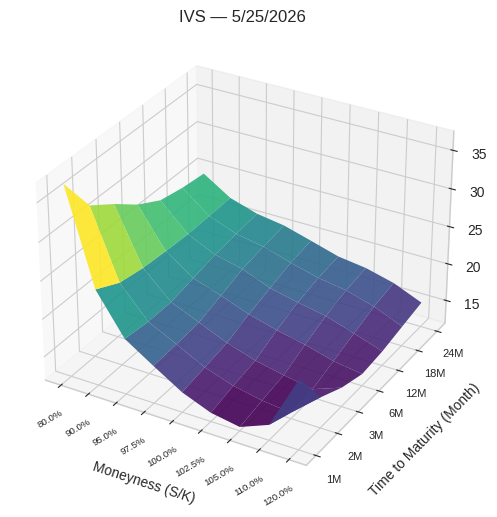

In [4]:
# Build MultiIndex columns: (time to maturity in months, moneyness in %)
value_cols = [c for c in iv_data.columns if c != "Dates"]

meta = pd.Series(value_cols).str.extract(
    r"(?P<tenor_num>\d+)(?P<tenor_unit>DAY|MTH)_IMPVOL_(?P<moneyness>[0-9.]+)%MNY_DF"
)

# Convert DAY/MTH tenor to numeric months and moneyness to numeric percent
months_num = np.where(
    meta["tenor_unit"].eq("DAY"),
    (meta["tenor_num"].astype(float) / 30.0).astype(int),
    meta["tenor_num"].astype(int),
)
moneyness_num = meta["moneyness"].astype(float)

# Keep sortable numeric levels, then label them after sorting
multi_cols = pd.MultiIndex.from_arrays(
    [months_num, moneyness_num],
    names=["Time to maturity (M)", "Moneyness (%)"],
)

# Surface dataframe with Dates as index and MultiIndex IV columns
iv_surface = iv_data.set_index("Dates")[value_cols].copy()
iv_surface.columns = multi_cols

# Create global sorted arrays of unique times to maturity and moneyness levels
time_to_maturity_levels = np.sort(iv_surface.columns.get_level_values("Time to maturity (M)").unique())
moneyness_levels = np.sort(iv_surface.columns.get_level_values("Moneyness (%)").unique())

# One matrix per date, reindexed using the global sorted levels
surface_matrices = {
    date: row.unstack("Moneyness (%)").reindex(index=time_to_maturity_levels, columns=moneyness_levels)
    for date, row in iv_surface.iterrows()
}

# Label row/column axes as requested (same order for every date)
time_to_maturity_labels = time_to_maturity_levels.astype(str) + "M"
moneyness_labels = moneyness_levels.astype(str) + "%"

for date in surface_matrices:
    mat = surface_matrices[date]
    mat.index = time_to_maturity_labels
    mat.columns = moneyness_labels

# surface index to show
selected_date = "5/25/2026"

print(f"dict shape: {len(surface_matrices)}, {surface_matrices[selected_date].shape}")
print("index: date, value: (time_to_maturity, moneyness)")
print(f"date: {selected_date}")
display(surface_matrices[selected_date]) 

mat0 = surface_matrices[selected_date]
X, Y = np.meshgrid(np.arange(mat0.shape[1]), np.arange(mat0.shape[0]))
Z = mat0.to_numpy()

fig = plt.figure(figsize=(6, 8))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(X, Y, Z, cmap="viridis", edgecolor="none", alpha=0.9)

ax.set_xticks(np.arange(mat0.shape[1]))
ax.set_xticklabels(mat0.columns, fontsize=7, rotation=30)
ax.set_yticks(np.arange(mat0.shape[0]))
ax.set_yticklabels(mat0.index, fontsize=8)

ax.set_xlabel("Moneyness (S/K)", labelpad=10)
ax.set_ylabel("Time to Maturity (Month)", labelpad=10)
ax.set_zlabel("Implied Volatility (%)", labelpad=8)
ax.set_title(f"IVS — {selected_date}")

plt.tight_layout()
safe_date = selected_date.replace('/', '-')
plt.savefig(f'ivs_{safe_date}.png', dpi=300, bbox_inches='tight')
plt.show()

### VAR(1) & VAR(p), p>1

In [ ]:
# statsmodels VAR requires string variable names.
flat_col_names = [f"{int(m)}M_{mon:g}%" for m, mon in iv_surface.columns]
Y_var = iv_surface.copy()
Y_var.columns = flat_col_names

# Train/test split: 80% old (train), 20% new (test)
n_obs = len(Y_var)
split_idx = int(n_obs * 0.8)
Y_train, Y_test = Y_var.iloc[:split_idx], Y_var.iloc[split_idx:]

print(f"Total observations: {n_obs}, train: {len(Y_train)}, test: {len(Y_test)}")

# Fit VAR(1)
var1_model = VAR(Y_train)
var1_res = var1_model.fit(1)
print(var1_res.summary()[0])

# Lag-1 coefficient matrix
A1 = var1_res.coefs[0]
print("A1 (lag-1 coefficient matrix) shape:", A1.shape)
A1_df = pd.DataFrame(A1, index=flat_col_names, columns=flat_col_names)
display(A1_df)

# Fit VAR(p) AIC
varp_model = VAR(Y_train)
varp_aic_res = varp_model.fit(maxlags=15, ic='aic')
varp_bic_res = varp_model.fit(maxlags=15, ic='bic')
print(f"Optimal p selected by AIC: {varp_aic_res.k_ar}")
print(f"Optimal p selected by BIC: {varp_bic_res.k_ar}")

NameError: name 'iv_surface' is not defined

### MAR(1)

In [6]:
# Convert the dictionary of DataFrames directly into a 3D NumPy array for fast operations
X_seq_all = np.stack([mat.to_numpy() for mat in surface_matrices.values()], axis=0)
X_seq = X_seq_all[:split_idx]

# Matrix dimensions (X_t is m x n)
m, n = X_seq_all.shape[1], X_seq_all.shape[2]

def rearrange_G(C, m, n):
    """
    Rearrangement operator G: R^{mn} x R^{mn} -> R^{m^2 x n^2}
    satisfying G(B kron A) = vec(A) vec(B)^T (vec uses column-major order).
    (Optimized with high-performance tensorial reshaping)
    """
    return C.reshape(n, m, n, m).transpose(2, 0, 3, 1).reshape(n * n, m * m).T

# Method 1: Projection (PROJ)
Phi_hat = A1.copy() # Use VAR(1) coefficient matrix
Phi_tilde = rearrange_G(Phi_hat, m, n)
U, S, Vt = np.linalg.svd(Phi_tilde, full_matrices=False)

d1 = S[0]
u1 = U[:, 0]
v1 = Vt[0, :]

# Rank-1 approximation: d1 * u1 v1^T = vec(A_hat_1) vec(B_hat_1)^T
vec_A_hat_1 = np.sqrt(d1) * u1
vec_B_hat_1 = np.sqrt(d1) * v1

A_proj = vec_A_hat_1.reshape((m, m), order="F")
B_proj = vec_B_hat_1.reshape((n, n), order="F")

# Identification: ||A||_F = 1 (adjust B accordingly)
scale_proj = np.linalg.norm(A_proj, ord="fro")
A_proj = A_proj / scale_proj
B_proj = B_proj * scale_proj

# Method 2: Iterated Least Squares (LSE)
def safe_inverse(M):
    try:
        return np.linalg.inv(M)
    except np.linalg.LinAlgError:
        return np.linalg.pinv(M)

A_ils = A_proj.copy()
B_ils = B_proj.copy()

tol = 1e-6
max_iter = 1000

# Vectorize time series datasets for 'np.einsum' speed optimizations
X1 = X_seq[1:]  # Represents X_{t}
X0 = X_seq[:-1] # Represents X_{t-1}

for it in range(1, max_iter + 1):
    A_prev = A_ils
    B_prev = B_ils

    # Update B holding A fixed (Vectorized sum over t)
    B_num = np.einsum('tmi,mk,tkj->ij', X1, A_ils, X0)
    B_den = np.einsum('tmi,mk,tkj->ij', X0, A_ils.T @ A_ils, X0)
    B_ils = B_num @ safe_inverse(B_den)

    # Update A holding B fixed (Vectorized sum over t)
    A_num = np.einsum('tik,kl,tjl->ij', X1, B_ils, X0)
    A_den = np.einsum('tik,kl,tjl->ij', X0, B_ils.T @ B_ils, X0)
    A_ils = A_num @ safe_inverse(A_den)

    # Enforce identification: ||A||_F = 1 and adjust B
    scale = np.linalg.norm(A_ils, ord="fro")
    A_ils = A_ils / scale
    B_ils = B_ils * scale

    dA = np.linalg.norm(A_ils - A_prev, ord="fro")
    dB = np.linalg.norm(B_ils - B_prev, ord="fro")
    if dA < tol and dB < tol:
        break

# Objective values for quick comparison (Vectorized predictions)
proj_preds = np.einsum('ij,tjk,kl->til', A_proj, X0, B_proj)
ils_preds = np.einsum('ij,tjk,kl->til', A_ils, X0, B_ils)
proj_sse = np.sum((X1 - proj_preds) ** 2)
ils_sse = np.sum((X1 - ils_preds) ** 2)

summary_mar = pd.DataFrame(
    {
        "method": ["PROJ", "LSE"],
        "iterations": [1, it],
        "fro_norm_A": [np.linalg.norm(A_proj, ord="fro"), np.linalg.norm(A_ils, ord="fro")],
        "objective_sse": [proj_sse, ils_sse],
    }
)

print("\nMAR(1) estimation summary")
display(summary_mar)

print("\nA_proj (PROJ):")
display(pd.DataFrame(A_proj))
print("B_proj (PROJ):")
display(pd.DataFrame(B_proj))
print("A_ils (LSE):")
display(pd.DataFrame(A_ils))
print("B_ils (ILS):")
display(pd.DataFrame(B_ils))


MAR(1) estimation summary


,method,iterations,fro_norm_A,objective_sse
0,PROJ,1,1.0,2.940788e+08
1,LSE,355,1.0,4.631447e+07



A_proj (PROJ):


,0,1,2,3,4,5,6
0,0.171145,-0.232012,0.162003,-0.042316,0.127624,-0.141177,0.022943
1,0.128775,-0.186170,0.154448,-0.049781,0.123106,-0.143377,0.032353
2,0.128092,-0.234372,0.190899,-0.034274,0.157317,-0.178288,0.027802
3,0.106891,-0.217149,0.181066,-0.034154,0.153182,-0.169354,0.030632
4,0.107542,-0.216878,0.183876,-0.037287,0.163397,-0.177596,0.029106
5,0.106149,-0.217344,0.186077,-0.036737,0.148675,-0.160758,0.026722
6,0.105108,-0.199435,0.171633,-0.038258,0.145943,-0.160792,0.030995


B_proj (PROJ):


,0,1,2,3,4,5,6,7,8
0,-0.402306,0.032214,-0.098423,1.199416,21.582063,1.704616,1.256390,-8.302213,-1.641141
1,-0.463956,0.567827,-0.717165,1.067417,15.195825,1.155911,2.538667,-4.765030,-1.583961
2,-0.497443,0.867713,-1.219978,1.607822,15.072270,0.913109,2.641512,-3.586167,-1.999611
3,-0.405670,0.731167,-0.731944,2.375894,13.916124,0.975093,2.631488,-3.563190,-1.529230
4,-0.618796,0.454976,-0.323934,1.703444,10.435761,1.008156,2.345986,-3.156239,-0.410472
5,-0.360904,0.727803,-0.036215,1.017921,5.816150,1.437065,1.687324,-1.960104,-0.257791
6,-0.208610,0.695702,-0.156243,0.951822,5.265900,0.900294,1.626900,-1.575192,-0.224243
7,-0.211877,0.616844,-0.042798,0.634506,5.175741,0.597531,1.099945,-1.447674,-0.013260
8,-0.203085,0.436619,0.288658,0.324500,4.915751,0.756675,0.808623,-1.811676,0.373566


A_ils (LSE):


,0,1,2,3,4,5,6
0,0.191815,0.364481,-0.120632,-0.058410,-0.016096,-0.051978,0.098050
1,-0.020974,0.353441,0.055434,0.031601,-0.038982,-0.093787,0.113577
2,-0.017620,0.020900,0.348541,0.072430,-0.034853,-0.077003,0.086360
3,-0.010016,0.002944,0.000399,0.392228,0.000734,0.032410,-0.021120
4,-0.008224,0.014213,-0.024574,0.044390,0.290879,0.170953,-0.089035
5,-0.006911,0.011270,-0.013530,0.002295,0.059733,0.295843,0.051403
6,-0.007509,0.009771,-0.000017,-0.008330,-0.018102,0.071936,0.353869


B_ils (ILS):


,0,1,2,3,4,5,6,7,8
0,3.037483,-1.262408,1.691167,-0.858448,-0.216491,0.095266,0.013062,0.032794,-0.093753
1,-0.028523,2.938612,-0.186851,-0.033960,-0.289912,-0.065819,0.366878,-0.116449,-0.149329
2,-0.211290,0.963469,1.522344,0.354864,-0.131816,-0.028637,0.273325,-0.162480,-0.139186
3,-0.165378,0.402414,0.377435,1.790539,0.082788,-0.016736,0.307896,-0.198687,-0.133643
4,-0.146654,0.404450,-0.663558,1.484585,0.809946,0.686472,0.264788,-0.283760,-0.108423
5,-0.180563,0.863824,-1.576810,1.003039,0.573878,0.995591,1.351247,-0.506220,-0.076631
6,-0.164419,0.999866,-1.944435,1.295930,0.185866,-0.614192,2.941341,-0.067722,-0.191516
7,-0.013061,0.440577,-1.221421,0.945891,0.202833,-0.413866,0.235392,2.362956,-0.094397
8,0.328328,-0.298943,-0.912048,0.983636,0.059130,-0.322384,0.734372,-0.518765,2.366127


### MAR Lasso

In [7]:
# Mean-center the data for stable LASSO estimation
X_mean = X_seq_all[:split_idx].mean(axis=0)
X_seq_mc = X_seq_all - X_mean
X1_mc = X_seq_mc[1:split_idx]
X0_mc = X_seq_mc[:split_idx - 1]

def lasso(alphas_A, alphas_B, n_splits):
    m, n = X_seq_all.shape[1], X_seq_all.shape[2]

    # Initialize with ILS coefficients
    A_lasso = A_ils.copy()
    B_lasso = B_ils.copy()

    best_alpha_A = None
    best_alpha_B = None
    best_cv_score = float('inf')

    tscv = TimeSeriesSplit(n_splits=n_splits)

    # 2D Grid Search Loop
    for alpha_A in alphas_A:
        for alpha_B in alphas_B:
            cv_scores = []
            
            for train_idx, val_idx in tscv.split(X1_mc):
                # 1. Update A (fixing B_lasso) on the training fold
                Z_A_train = np.einsum('ijk,lk->ijl', X0_mc[train_idx], B_lasso).reshape(-1, m)
                Y_train_A = X1_mc[train_idx].reshape(-1, m)
                
                lasso_A_temp = Lasso(alpha=alpha_A, fit_intercept=False, max_iter=200, tol=1e-3)
                lasso_A_temp.fit(Z_A_train, Y_train_A)
                temp_A = lasso_A_temp.coef_.T 
                
                # 2. Update B (fixing the new temp_A) on the training fold
                Z_B_train = np.einsum('ij,tjk->tik', temp_A, X0_mc[train_idx]).reshape(-1, n)
                Y_train_B = X1_mc[train_idx].reshape(-1, n)
                
                lasso_B_temp = Lasso(alpha=alpha_B, fit_intercept=False, max_iter=200, tol=1e-3)
                lasso_B_temp.fit(Z_B_train, Y_train_B)
                temp_B = lasso_B_temp.coef_ 
                
                # 3. Evaluate the combined (temp_A, temp_B) on the validation fold
                preds = np.einsum('ij,tjk,lk->til', temp_A, X0_mc[val_idx], temp_B)
                mse = mean_squared_error(X1_mc[val_idx].flatten(), preds.flatten())
                cv_scores.append(mse)
                
            avg_mse = np.mean(cv_scores)
            
            if avg_mse < best_cv_score:
                best_cv_score = avg_mse
                best_alpha_A = alpha_A
                best_alpha_B = alpha_B

    print(f"Optimal L1 penalty for A (lambda_1): {best_alpha_A:.5f}")
    print(f"Optimal L1 penalty for B (lambda_2): {best_alpha_B:.5f}")
    print(f"Best CV MSE: {best_cv_score:.6f}")

    # Final Convergence Loop using optimal alphas
    lasso_A_final = Lasso(alpha=best_alpha_A, fit_intercept=False, max_iter=2000, warm_start=True)
    lasso_B_final = Lasso(alpha=best_alpha_B, fit_intercept=False, max_iter=2000, warm_start=True)

    tol_lasso = 1e-6
    max_iter_lasso = 50

    for it in range(1, max_iter_lasso + 1):
        A_prev = A_lasso.copy()
        B_prev = B_lasso.copy()

        # 1. Update B holding A fixed
        Z_A = np.einsum('ij,tjk->tik', A_lasso, X0_mc)
        lasso_B_final.fit(Z_A.reshape(-1, n), X1_mc.reshape(-1, n))
        B_lasso = lasso_B_final.coef_.copy()

        # 2. Update A holding B fixed
        Z_B = np.einsum('tij,kj->tik', X0_mc, B_lasso)
        lasso_A_final.fit(Z_B.transpose(0, 2, 1).reshape(-1, m), X1_mc.transpose(0, 2, 1).reshape(-1, m))
        A_lasso = lasso_A_final.coef_.copy()

        # 3. Enforce identification: ||A||_F = 1 and adjust B
        scale = np.linalg.norm(A_lasso, ord="fro")
        if scale > 0:
            A_lasso = A_lasso / scale
            B_lasso = B_lasso * scale

        # Check convergence
        dA = np.linalg.norm(A_lasso - A_prev, ord="fro")
        dB = np.linalg.norm(B_lasso - B_prev, ord="fro")
        if dA < tol_lasso and dB < tol_lasso:
            print(f"MAR-LASSO converged at iteration {it}\n")
            break

    # IMPORTANT: Return statement was indented incorrectly in your code!
    return A_lasso, B_lasso 

print("--- Training LASSO Model 1 (Short-Term Focus) ---")
alphas_A_1 = np.logspace(-4, -1, 4) 
alphas_B_1 = np.logspace(-4, -1, 4) 
A_lasso_1, B_lasso_1 = lasso(alphas_A_1, alphas_B_1, 3)

print("--- Training LASSO Model 2 (Long-Term Focus) ---")
alphas_A_2 = np.logspace(-5, 5, 10) 
alphas_B_2 = np.logspace(-5, 5, 10) # Fixed typo here from -5 to 5
A_lasso_2, B_lasso_2 = lasso(alphas_A_2, alphas_B_2, 5)

--- Training LASSO Model 1 (Short-Term Focus) ---
Optimal L1 penalty for A (lambda_1): 0.10000
Optimal L1 penalty for B (lambda_2): 0.00100
Best CV MSE: 1.761308
MAR-LASSO converged at iteration 8

--- Training LASSO Model 2 (Long-Term Focus) ---
Optimal L1 penalty for A (lambda_1): 3.59381
Optimal L1 penalty for B (lambda_2): 0.00167
Best CV MSE: 1.704284
MAR-LASSO converged at iteration 10



### Evaluate VAR(1), VAR(p) AIC, MAR(1), MAR(1) Lasso

In [8]:
horizons = [1, 5, 10, 15, 20, 25, 30, 60, 90]
start_i = split_idx
optimal_p = varp_aic_res.k_ar

# Dictionaries to store the results
mse_var1_results = {}
mse_varp_results = {}
mse_mar_ils_results = {}
mse_mar_lasso_1_results = {} # For Model 1
mse_mar_lasso_2_results = {} # For Model 2

# List to collect prediction data for plotting
plot_rows = []

for h in horizons:
    # Precompute MAR(1) matrix powers for the h-step forecast
    A_ils_h = np.linalg.matrix_power(A_ils, h)
    B_ils_h = np.linalg.matrix_power(B_ils, h)
    
    A_lasso_1_h = np.linalg.matrix_power(A_lasso_1, h)
    B_lasso_1_h = np.linalg.matrix_power(B_lasso_1, h)
    
    A_lasso_2_h = np.linalg.matrix_power(A_lasso_2, h)
    B_lasso_2_h = np.linalg.matrix_power(B_lasso_2, h)
    
    # Lists to store errors for this horizon
    sq_err_var1 = []
    sq_err_varp = []
    sq_err_ils = []
    sq_err_lasso_1 = []
    sq_err_lasso_2 = []
    
    end_i = n_obs - h + 1

    for i in range(start_i, end_i):
        # 1. Fetch Targets
        actual_h = Y_var.iloc[i + h - 1].to_numpy()  # 1D array for VAR
        X_target = X_seq_all[i + h - 1]              # 2D matrix for MAR
        date_val = Y_var.index[i + h - 1]            # Fetch the corresponding date
        
        # 2. VAR(1) Forecast
        last_obs_1 = Y_var.iloc[i - 1 : i].to_numpy()
        pred_var1 = var1_res.forecast(last_obs_1, steps=h)[-1]
        sq_err_var1.append((actual_h - pred_var1) ** 2)
        
        # 3. VAR(p) Forecast
        last_obs_p = Y_var.iloc[i - optimal_p : i].to_numpy() 
        pred_varp = varp_aic_res.forecast(last_obs_p, steps=h)[-1]
        sq_err_varp.append((actual_h - pred_varp) ** 2)

        # 4. MAR Forecasts
        X_origin = X_seq_all[i - 1]
        X_pred_ils = A_ils_h @ X_origin @ B_ils_h.T
        
        # 5. MAR-LASSO Forecasts (utilizing mean-centering adjustment)
        X_origin_mc = X_origin - X_mean
        
        X_pred_lasso_1_mc = A_lasso_1_h @ X_origin_mc @ B_lasso_1_h.T
        X_pred_lasso_1 = X_pred_lasso_1_mc + X_mean
        
        X_pred_lasso_2_mc = A_lasso_2_h @ X_origin_mc @ B_lasso_2_h.T
        X_pred_lasso_2 = X_pred_lasso_2_mc + X_mean
        
        # Flatten matrix differences to calculate MSE uniformly over all m*n elements
        sq_err_ils.append((X_target - X_pred_ils).flatten() ** 2)
        sq_err_lasso_1.append((X_target - X_pred_lasso_1).flatten() ** 2)
        sq_err_lasso_2.append((X_target - X_pred_lasso_2).flatten() ** 2)
        
        # Append predictions for plotting
        plot_rows.append({
            "horizon_days": h,
            "date": date_val,
            "actual_mean_iv": actual_h.mean(),
            "var1_mean_iv": pred_var1.mean(),
            "varp_mean_iv": pred_varp.mean(),
            "mar_ils_mean_iv": X_pred_ils.mean(),
            "mar_lasso_1_mean_iv": X_pred_lasso_1.mean(),
            "mar_lasso_2_mean_iv": X_pred_lasso_2.mean(),
        })
        
    # Calculate mean squared error for this horizon (h) across all time steps
    mse_var1_results[h] = np.vstack(sq_err_var1).mean()
    mse_varp_results[h] = np.vstack(sq_err_varp).mean()
    mse_mar_ils_results[h] = np.vstack(sq_err_ils).mean()
    mse_mar_lasso_1_results[h] = np.vstack(sq_err_lasso_1).mean()
    mse_mar_lasso_2_results[h] = np.vstack(sq_err_lasso_2).mean()

# Compile everything into a single, clean DataFrame
mse_df = pd.DataFrame({
    "horizon_days": horizons,
    "VAR(1)": list(mse_var1_results.values()),
    f"VAR({optimal_p}) AIC": list(mse_varp_results.values()),
    "MAR(1)": list(mse_mar_ils_results.values()),
    "MAR(1) LASSO S": list(mse_mar_lasso_1_results.values()),
    "MAR(1) LASSO L": list(mse_mar_lasso_2_results.values()),
})

# Format pandas display to strictly use regular floats (no scientific 'e' notation)
pd.options.display.float_format = '{:.6f}'.format

print("Updated MSE table across all models:")
display(mse_df)

Updated MSE table across all models:


,horizon_days,VAR(1),VAR(15) AIC,MAR(1),MAR(1) LASSO S,MAR(1) LASSO L
0,1,0.892811,2.449752,0.807604,0.809843,0.975549
1,5,3.151233,7.928848,2.975407,2.866942,3.277966
2,10,4.482523,9.946407,5.208234,4.366054,4.465034
3,15,5.139086,10.427872,8.614460,5.554712,5.192720
4,20,5.201370,9.950108,15.604119,6.973986,5.607079
5,25,5.887866,10.197602,33.354503,9.677334,5.935594
6,30,6.230838,10.768629,85.486073,13.665248,6.012869
7,60,7.366890,13.719187,74965.177300,115.340426,5.669976
8,90,6.641381,14.421588,136915836.322524,413.356466,5.663717


### Visualize errors and predictions

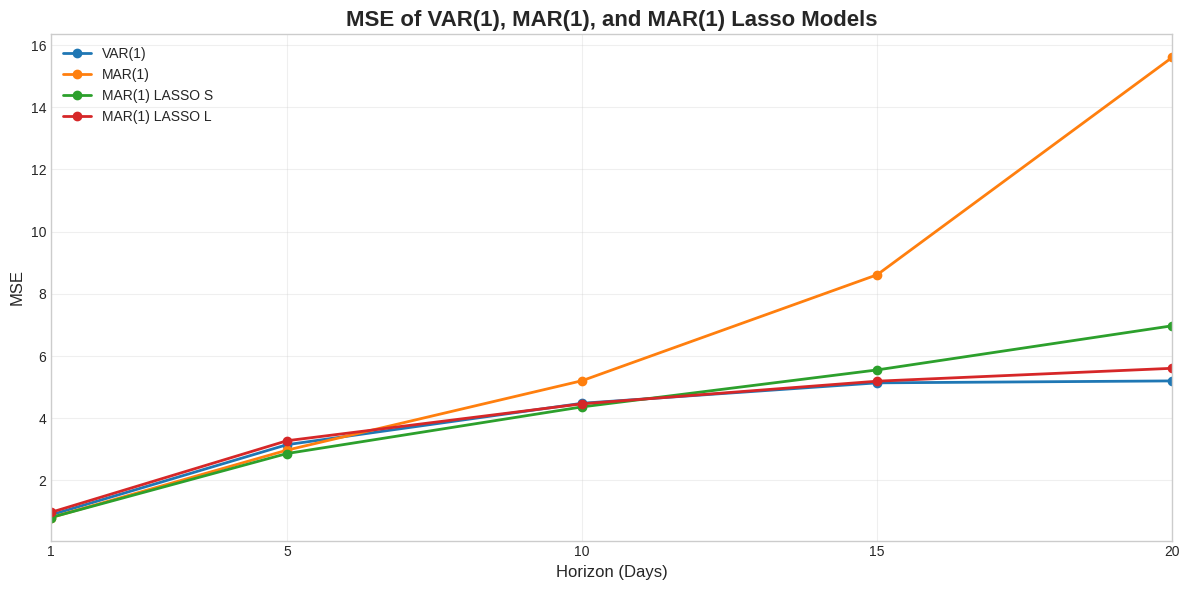

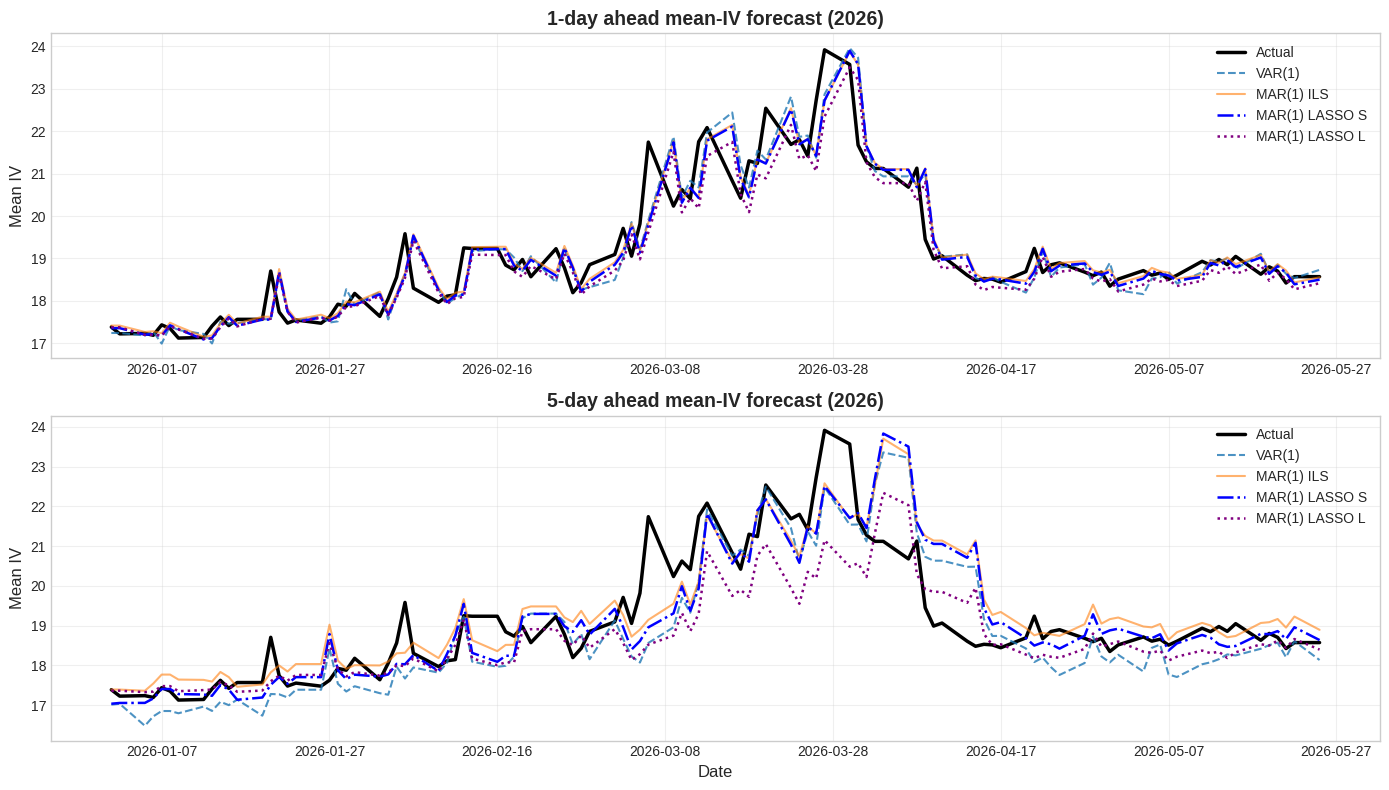

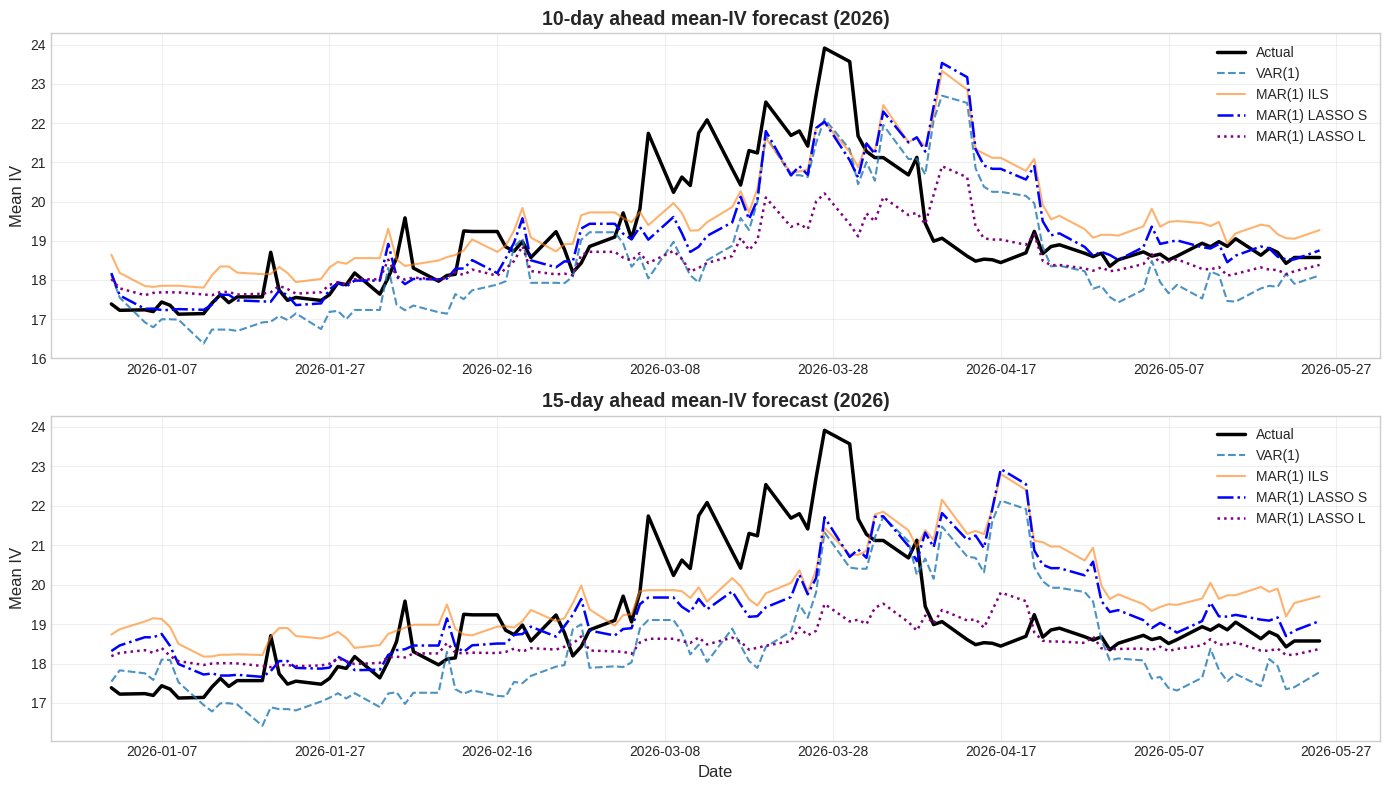

In [9]:
# --- 1. MSE COMPARISON PLOT ---
# Plot up to the 20-day horizon (which is the first 5 elements if your horizons are 1, 5, 10, 15, 20...)
mse_20d = mse_df.head(5) 

plt.figure(figsize=(12, 6))
for col in mse_20d.columns:
    # Exclude the x-axis column and the VAR(p) model to keep the plot clean
    if col != "horizon_days" and col != f"VAR({optimal_p}) AIC":
        plt.plot(mse_20d["horizon_days"], mse_20d[col], marker='o', linewidth=2, label=col)

plt.title("MSE of VAR(1), MAR(1), and MAR(1) Lasso Models", fontsize=16, fontweight="bold")
plt.xlabel("Horizon (Days)", fontsize=12)
plt.ylabel("MSE", fontsize=12)
plt.xlim(1, 20)
plt.xticks([h for h in horizons if h <= 20])
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("MSEComp.png")
plt.show()


# --- 2. PREDICTED VS ACTUAL TIME-SERIES PLOTS ---
plot_df = pd.DataFrame(plot_rows)

# Convert date strings to datetime objects if they aren't already
plot_df["date"] = pd.to_datetime(plot_df["date"])
horizons_to_plot1 = [1, 5]
horizons_to_plot2 = [10, 15]

# Filter for the year 2026
plot_df_2026 = plot_df[plot_df["date"].dt.year == 2026].copy()

def plt_data(horizons_to_plot):
    # Create a figure with a subplot for each horizon
    fig, axes = plt.subplots(len(horizons_to_plot), 1, figsize=(14, 4 * len(horizons_to_plot)), sharex=False)
    
    # Ensure axes is iterable if only 1 horizon is passed
    if len(horizons_to_plot) == 1:
        axes = [axes]  

    for ax, h in zip(axes, horizons_to_plot):
        df_h = plot_df_2026[plot_df_2026["horizon_days"] == h].copy()
        
        # Plot Actual Data
        ax.plot(df_h["date"], df_h["actual_mean_iv"], label="Actual", linewidth=2.5, color='black')
        
        # Plot VAR Model
        ax.plot(df_h["date"], df_h["var1_mean_iv"], label="VAR(1)", linewidth=1.5, linestyle='--', alpha=0.8)
        
        # Plot MAR Unregularized
        ax.plot(df_h["date"], df_h["mar_ils_mean_iv"], label="MAR(1) ILS", linewidth=1.5, alpha=0.6)
        
        # Plot BOTH MAR-LASSO Models
        # Model 1 (Short-term focus) is dash-dot
        ax.plot(df_h["date"], df_h["mar_lasso_1_mean_iv"], label="MAR(1) LASSO S", linewidth=1.8, linestyle='-.', color='blue')
        # Model 2 (Long-term focus) is dotted
        ax.plot(df_h["date"], df_h["mar_lasso_2_mean_iv"], label="MAR(1) LASSO L", linewidth=1.8, linestyle=':', color='purple')
        
        # Formatting
        ax.set_title(f"{h}-day ahead mean-IV forecast (2026)", fontsize=14, fontweight='bold')
        ax.set_ylabel("Mean IV", fontsize=12)
        ax.grid(alpha=0.3)
        ax.legend(loc='best', fontsize=10)
        
        # Reduce x-ticks density if there are too many dates
        ax.xaxis.set_major_locator(plt.MaxNLocator(10)) 

    plt.xlabel("Date", fontsize=12)
    plt.tight_layout()

# Generate and save the short-horizon plots (1d, 5d)
plt_data(horizons_to_plot1)
plt.savefig("short-horizon-forecast.png")
plt.show()

# Generate and save the longer-horizon plots (10d, 15d)
plt_data(horizons_to_plot2)
plt.savefig("long-horizon-forecast.png")
plt.show()

### LSTM

In [10]:
seq_len = 1  # Use the same lookback window as VAR(p) for fair comparison
k_vars = Y_var.shape[1]

# Neural Networks require scaled data to converge properly
scaler = StandardScaler()
Y_train_scaled = scaler.fit_transform(Y_train)
Y_var_scaled = scaler.transform(Y_var)

# Build training sequences
X_train_seq = []
y_train_seq = []
for t in range(seq_len, len(Y_train_scaled)):
    X_train_seq.append(Y_train_scaled[t - seq_len : t])
    y_train_seq.append(Y_train_scaled[t])

X_train_seq = np.array(X_train_seq)
y_train_seq = np.array(y_train_seq)

# Create PyTorch DataLoader
train_dataset = TensorDataset(
    torch.tensor(X_train_seq, dtype=torch.float32),
    torch.tensor(y_train_seq, dtype=torch.float32)
)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)


# Build Models: Vanilla vs Residual

class VanillaIVLSTM(pl.LightningModule):
    """The original LSTM that struggles to learn the identity function."""
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        last_out = lstm_out[:, -1, :]
        return self.fc(last_out)

    def training_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)
        loss = nn.functional.mse_loss(y_hat, y)
        return loss

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=1e-3)


class ResidualIVLSTM(pl.LightningModule):
    """The improved LSTM using Residual Connections & Regularization."""
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.dropout = nn.Dropout(0.2)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        last_hidden_state = self.dropout(lstm_out[:, -1, :])
        delta = self.fc(last_hidden_state)
        # Residual connection
        last_observation = x[:, -1, :] 
        return last_observation + delta

    def training_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)
        loss = nn.functional.mse_loss(y_hat, y)
        return loss

    def configure_optimizers(self):
        # L2 Regularization (weight_decay)
        return torch.optim.Adam(self.parameters(), lr=1e-3, weight_decay=1e-4)


# Initialize Models
vanilla_lstm = VanillaIVLSTM(input_dim=k_vars, hidden_dim=64, output_dim=k_vars)
residual_lstm = ResidualIVLSTM(input_dim=k_vars, hidden_dim=32, output_dim=k_vars)

trainer_kws = dict(enable_progress_bar=False, enable_model_summary=False, enable_checkpointing=False, logger=False)

print("Training Vanilla LSTM...")
pl.Trainer(max_epochs=20, **trainer_kws).fit(vanilla_lstm, train_loader)

print("Training Residual LSTM...")
pl.Trainer(max_epochs=30, **trainer_kws).fit(residual_lstm, train_loader)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Training Vanilla LSTM...


`Trainer.fit` stopped: `max_epochs=20` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Training Residual LSTM...


`Trainer.fit` stopped: `max_epochs=30` reached.


In [11]:
vanilla_lstm.eval()
residual_lstm.eval()

H_max = max(horizons)
start_i = split_idx

# Identify all test origins
all_test_origins = list(range(start_i - 1, n_obs - 1))
X_test_origins = np.stack([Y_var_scaled[idx - seq_len + 1 : idx + 1] for idx in all_test_origins])

def generate_forecasts(model, initial_seqs, steps):
    forecasts_scaled = np.zeros((len(all_test_origins), steps, k_vars))
    curr_seqs = initial_seqs.copy()
    
    with torch.no_grad():
        for step in range(steps):
            seq_tensor = torch.tensor(curr_seqs, dtype=torch.float32)
            preds = model(seq_tensor).numpy()
            forecasts_scaled[:, step, :] = preds
            
            preds_exp = np.expand_dims(preds, axis=1)
            curr_seqs = np.concatenate([curr_seqs[:, 1:, :], preds_exp], axis=1)
            
    # Inverse transform to absolute IV scale
    return scaler.inverse_transform(forecasts_scaled.reshape(-1, k_vars)).reshape(-1, steps, k_vars)

vanilla_forecasts_unscaled = generate_forecasts(vanilla_lstm, X_test_origins, H_max)
residual_forecasts_unscaled = generate_forecasts(residual_lstm, X_test_origins, H_max)

# Evaluate
mse_vanilla_results = {}
mse_residual_results = {}
lstm_plot_data = []

for h in horizons:
    sq_err_vanilla = []
    sq_err_residual = []
    end_i = n_obs - h + 1

    for i in range(start_i, end_i):
        actual_h = Y_var.iloc[i + h - 1].to_numpy()
        date_val = Y_var.index[i + h - 1]
        
        rel_idx = (i - 1) - (start_i - 1)
        
        vanilla_pred_h = vanilla_forecasts_unscaled[rel_idx, h - 1, :]
        residual_pred_h = residual_forecasts_unscaled[rel_idx, h - 1, :]
        
        sq_err_vanilla.append((actual_h - vanilla_pred_h) ** 2)
        sq_err_residual.append((actual_h - residual_pred_h) ** 2)
        
        lstm_plot_data.append({
            "horizon_days": h,
            "date": pd.to_datetime(date_val),
            "lstm_vanilla_mean_iv": vanilla_pred_h.mean(),
            "lstm_residual_mean_iv": residual_pred_h.mean()
        })
        
    mse_vanilla_results[h] = np.vstack(sq_err_vanilla).mean()
    mse_residual_results[h] = np.vstack(sq_err_residual).mean()

mse_df["Vanilla LSTM"] = mse_df["horizon_days"].map(mse_vanilla_results)
mse_df["Residual LSTM"] = mse_df["horizon_days"].map(mse_residual_results)

print("\nUpdated MSE table across all models:")
display(mse_df)


Updated MSE table across all models:


,horizon_days,VAR(1),VAR(15) AIC,MAR(1),MAR(1) LASSO S,MAR(1) LASSO L,Vanilla LSTM,Residual LSTM
0,1,0.892811,2.449752,0.807604,0.809843,0.975549,1.119789,0.810694
1,5,3.151233,7.928848,2.975407,2.866942,3.277966,6.461705,2.954790
2,10,4.482523,9.946407,5.208234,4.366054,4.465034,12.571810,4.418450
3,15,5.139086,10.427872,8.614460,5.554712,5.192720,16.451497,5.341888
4,20,5.201370,9.950108,15.604119,6.973986,5.607079,18.347492,5.619182
5,25,5.887866,10.197602,33.354503,9.677334,5.935594,19.556726,6.439302
6,30,6.230838,10.768629,85.486073,13.665248,6.012869,20.163797,6.896035
7,60,7.366890,13.719187,74965.177300,115.340426,5.669976,24.875824,8.153568
8,90,6.641381,14.421588,136915836.322524,413.356466,5.663717,25.915788,7.766351


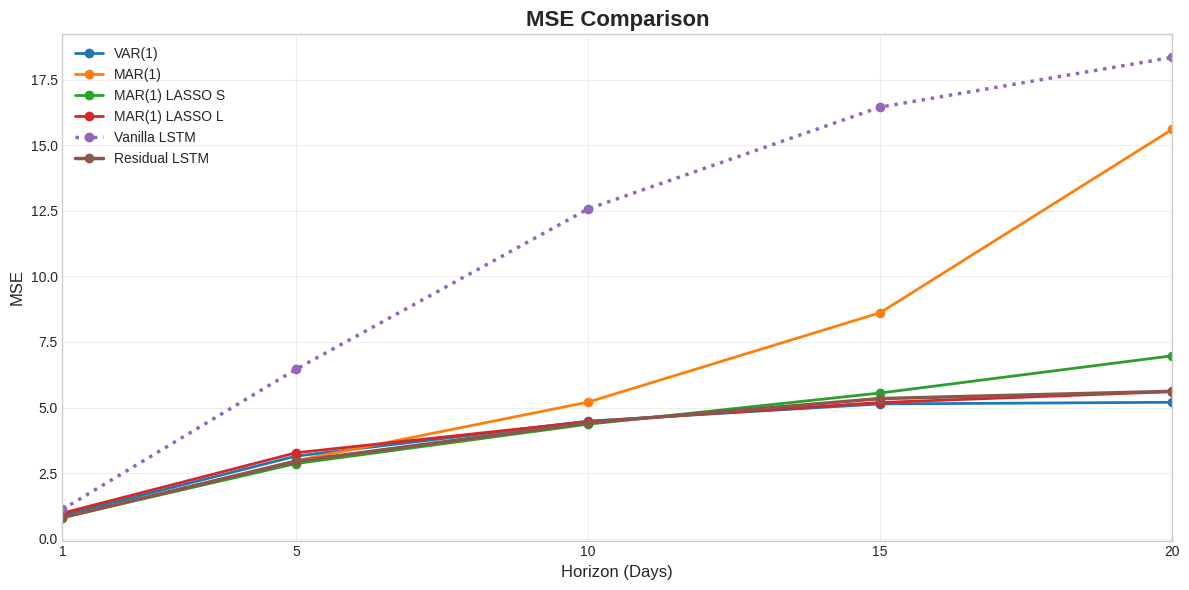

In [18]:
mse_20d = mse_df[mse_df["horizon_days"] <= 20]

plt.figure(figsize=(12, 6))
for col in mse_20d.columns:
    # FIXED: Hardcoded 'VAR(15) AIC' to prevent NameError on optimal_p
    if col != "horizon_days" and col != "VAR(15) AIC":
        
        # Make the Vanilla LSTM dotted so we can distinguish it visually
        linestyle = ':' if 'Vanilla' in col else '-'
        linewidth = 2.5 if 'LSTM' in col else 2.0
        
        plt.plot(mse_20d["horizon_days"], mse_20d[col], marker='o', 
                 linewidth=linewidth, linestyle=linestyle, label=col)

plt.title("MSE Comparison", fontsize=16, fontweight="bold")
plt.xlabel("Horizon (Days)", fontsize=12)
plt.ylabel("MSE", fontsize=12)
plt.xlim(1, 20)

# Extract horizons safely from the dataframe for the x-ticks
valid_horizons = mse_20d["horizon_days"].tolist()
plt.xticks(valid_horizons)

plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("MSE_LSTM.png")
plt.show()